In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TORCH_HOME"] = r"D:\torch_cache"

stimuli_path = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\stimuli_data"
brain_dir = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\brain_data"
results_dir = r"D:\Unravelling-Brain-Func-LAION\Ruxandra\results"

print("Setup ready.")
print("Stimuli:", len(os.listdir(stimuli_path)))

Setup ready.
Stimuli: 50


In [4]:
# Load grouped Taskonomy RDMs

rdm_2d = np.load(
    os.path.join(results_dir, "2D_RDM.npz"),
    allow_pickle=True
)["rdm"]

rdm_3d = np.load(
    os.path.join(results_dir, "3D_RDM.npz"),
    allow_pickle=True
)["rdm"]

rdm_semantic = np.load(
    os.path.join(results_dir, "Semantic_RDM.npz"),
    allow_pickle=True
)["rdm"]

print("2D RDM:", rdm_2d.shape)
print("3D RDM:", rdm_3d.shape)
print("Semantic RDM:", rdm_semantic.shape)

2D RDM: (1225,)
3D RDM: (1225,)
Semantic RDM: (1225,)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TORCH_HOME"] = r"D:\torch_cache"

stimuli_path = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\stimuli_data"
brain_dir = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\brain_data"
results_dir = r"D:\Unravelling-Brain-Func-LAION\Ruxandra\results"

print("Setup ready.")
print("Stimuli:", len(os.listdir(stimuli_path)))

In [2]:
# Load grouped Taskonomy RDMs

rdm_2d = np.load(
    os.path.join(results_dir, "2D_RDM.npz"),
    allow_pickle=True
)["rdm"]

rdm_3d = np.load(
    os.path.join(results_dir, "3D_RDM.npz"),
    allow_pickle=True
)["rdm"]

rdm_semantic = np.load(
    os.path.join(results_dir, "Semantic_RDM.npz"),
    allow_pickle=True
)["rdm"]

print("2D RDM:", rdm_2d.shape)
print("3D RDM:", rdm_3d.shape)
print("Semantic RDM:", rdm_semantic.shape)

NameError: name 'np' is not defined

In [5]:
# Check brain data folder

print("Brain directory:", brain_dir)
print("\nFiles:")
for f in os.listdir(brain_dir):
    print(f)

Brain directory: D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\brain_data

Files:
fmri_hV4.npz
fmri_LO1.npz
fmri_LO2.npz
fmri_PHC1.npz
fmri_PHC2.npz
fmri_V1d.npz
fmri_V1v.npz
fmri_V2d.npz
fmri_V2v.npz
fmri_V3a.npz
fmri_V3b.npz
fmri_V3d.npz
fmri_V3v.npz
fmri_VO1.npz
fmri_VO2.npz
noise_ceiling_log.json


In [6]:
# Inspect one fMRI file

test_file = os.path.join(brain_dir, "fmri_V1v.npz")
data = np.load(test_file, allow_pickle=True)

print("Keys:", data.files)

for key in data.files:
    print(key, "shape:", data[key].shape)

Keys: ['arr_0']
arr_0 shape: (16, 50, 50)


In [7]:
# Load all brain RDMs

brain_rdms = {}

for filename in os.listdir(brain_dir):
    if filename.startswith("fmri_") and filename.endswith(".npz"):
        roi = filename.replace("fmri_", "").replace(".npz", "")

        path = os.path.join(brain_dir, filename)
        data = np.load(path, allow_pickle=True)["arr_0"]

        brain_rdms[roi] = data

        print(roi, "->", data.shape)

print("\nNumber of ROIs:", len(brain_rdms))

hV4 -> (16, 50, 50)
LO1 -> (16, 50, 50)
LO2 -> (16, 50, 50)
PHC1 -> (16, 50, 50)
PHC2 -> (16, 50, 50)
V1d -> (16, 50, 50)
V1v -> (16, 50, 50)
V2d -> (16, 50, 50)
V2v -> (16, 50, 50)
V3a -> (16, 50, 50)
V3b -> (16, 50, 50)
V3d -> (16, 50, 50)
V3v -> (16, 50, 50)
VO1 -> (16, 50, 50)
VO2 -> (16, 50, 50)

Number of ROIs: 15


In [8]:
# Convert brain RDMs from 50x50 matrices to 1225-element vectors

brain_vectors = {}

upper_triangle = np.triu_indices(50, k=1)

for roi, rdms in brain_rdms.items():
    vectors = np.array([
        rdm[upper_triangle]
        for rdm in rdms
    ])

    brain_vectors[roi] = vectors
    print(roi, "->", vectors.shape)

hV4 -> (16, 1225)
LO1 -> (16, 1225)
LO2 -> (16, 1225)
PHC1 -> (16, 1225)
PHC2 -> (16, 1225)
V1d -> (16, 1225)
V1v -> (16, 1225)
V2d -> (16, 1225)
V2v -> (16, 1225)
V3a -> (16, 1225)
V3b -> (16, 1225)
V3d -> (16, 1225)
V3v -> (16, 1225)
VO1 -> (16, 1225)
VO2 -> (16, 1225)


In [48]:
# Prepare Taskonomy predictors for UVP

X = np.column_stack([
    rdm_2d,
    rdm_3d,
    rdm_semantic
])

print("Predictor matrix shape:", X.shape)

print("2D range:", np.min(rdm_2d), np.max(rdm_2d))
print("3D range:", np.min(rdm_3d), np.max(rdm_3d))
print("Semantic range:", np.min(rdm_semantic), np.max(rdm_semantic))

Predictor matrix shape: (1225, 3)
2D range: 0.22050719 0.8383723
3D range: 0.16740447 0.9132905
Semantic range: 0.12129178 0.5290397


In [10]:
Predictor matrix shape: (1225, 3)

SyntaxError: invalid syntax (3505686972.py, line 1)

In [12]:
# UVP for all ROIs and subjects

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

results = []

for roi, subject_vectors in brain_vectors.items():

    for subject_idx, y in enumerate(subject_vectors):

        # Full model
        full_model = LinearRegression().fit(X, y)
        full_pred = full_model.predict(X)
        r2_full = r2_score(y, full_pred)

        # Without 2D
        X_no_2d = np.column_stack([rdm_3d, rdm_semantic])
        model_no_2d = LinearRegression().fit(X_no_2d, y)
        pred_no_2d = model_no_2d.predict(X_no_2d)
        r2_no_2d = r2_score(y, pred_no_2d)

        # Without 3D
        X_no_3d = np.column_stack([rdm_2d, rdm_semantic])
        model_no_3d = LinearRegression().fit(X_no_3d, y)
        pred_no_3d = model_no_3d.predict(X_no_3d)
        r2_no_3d = r2_score(y, pred_no_3d)

        # Without Semantic
        X_no_sem = np.column_stack([rdm_2d, rdm_3d])
        model_no_sem = LinearRegression().fit(X_no_sem, y)
        pred_no_sem = model_no_sem.predict(X_no_sem)
        r2_no_sem = r2_score(y, pred_no_sem)

        # Unique variance
        unique_2d = r2_full - r2_no_2d
        unique_3d = r2_full - r2_no_3d
        unique_semantic = r2_full - r2_no_sem

        # Remaining explained variance
        shared = r2_full - unique_2d - unique_3d - unique_semantic

        results.append({
            "ROI": roi,
            "Subject": subject_idx + 1,
            "R2_full": r2_full,
            "Unique_2D": unique_2d,
            "Unique_3D": unique_3d,
            "Unique_Semantic": unique_semantic,
            "Shared": shared
        })

uvp_df = pd.DataFrame(results)

print(uvp_df.head())
print("\nRows:", len(uvp_df))

   ROI  Subject   R2_full  Unique_2D  Unique_3D  Unique_Semantic    Shared
0  hV4        1  0.007387   0.001000   0.001124         0.000027  0.005236
1  hV4        2  0.008775   0.003358   0.000545         0.000339  0.004533
2  hV4        3  0.004765   0.003118   0.000740         0.000170  0.000737
3  hV4        4  0.069800   0.015804   0.001196         0.001138  0.051663
4  hV4        5  0.063555   0.012347   0.000483         0.002792  0.047933

Rows: 240


In [13]:
# Average UVP across subjects for each ROI

uvp_summary = (
    uvp_df
    .groupby("ROI")[["R2_full", "Unique_2D", "Unique_3D", "Unique_Semantic", "Shared"]]
    .mean()
    .reset_index()
)

print(uvp_summary)

     ROI   R2_full  Unique_2D  Unique_3D  Unique_Semantic    Shared
0    LO1  0.006453   0.003745   0.001159         0.000566  0.000983
1    LO2  0.006393   0.003315   0.001280         0.000581  0.001216
2   PHC1  0.009283   0.004583   0.002015         0.001498  0.001187
3   PHC2  0.005814   0.003800   0.001453         0.000674 -0.000113
4    V1d  0.075595   0.022315   0.001651         0.006241  0.045388
5    V1v  0.086889   0.015491   0.001655         0.012162  0.057582
6    V2d  0.037995   0.019983   0.001550         0.001042  0.015420
7    V2v  0.044027   0.008449   0.001390         0.004736  0.029451
8    V3a  0.012661   0.006591   0.001124         0.000872  0.004074
9    V3b  0.006329   0.003953   0.000863         0.000383  0.001130
10   V3d  0.023205   0.013603   0.001385         0.000753  0.007464
11   V3v  0.030440   0.006887   0.001064         0.002705  0.019785
12   VO1  0.013161   0.004018   0.001133         0.001603  0.006407
13   VO2  0.009810   0.003844   0.001668        

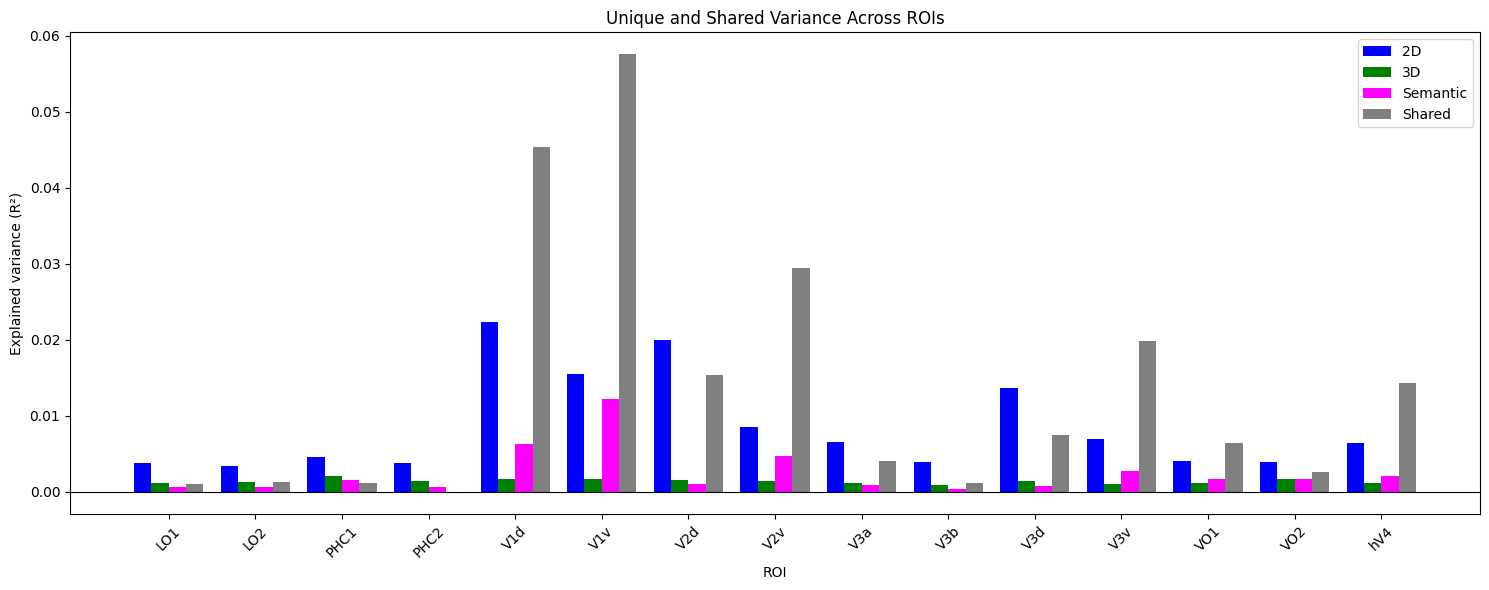

In [14]:
# Plot mean UVP across subjects for each ROI

roi_order = uvp_summary["ROI"].tolist()
x = np.arange(len(roi_order))
width = 0.20

plt.figure(figsize=(15, 6))

plt.bar(
    x - 1.5 * width,
    uvp_summary["Unique_2D"],
    width,
    label="2D",
    color="blue"
)

plt.bar(
    x - 0.5 * width,
    uvp_summary["Unique_3D"],
    width,
    label="3D",
    color="green"
)

plt.bar(
    x + 0.5 * width,
    uvp_summary["Unique_Semantic"],
    width,
    label="Semantic",
    color="magenta"
)

plt.bar(
    x + 1.5 * width,
    uvp_summary["Shared"],
    width,
    label="Shared",
    color="gray"
)

plt.xticks(x, roi_order, rotation=45)
plt.ylabel("Explained variance (R²)")
plt.xlabel("ROI")
plt.title("Unique and Shared Variance Across ROIs")
plt.axhline(0, linewidth=0.8, color="black")
plt.legend()

plt.tight_layout()
plt.show()

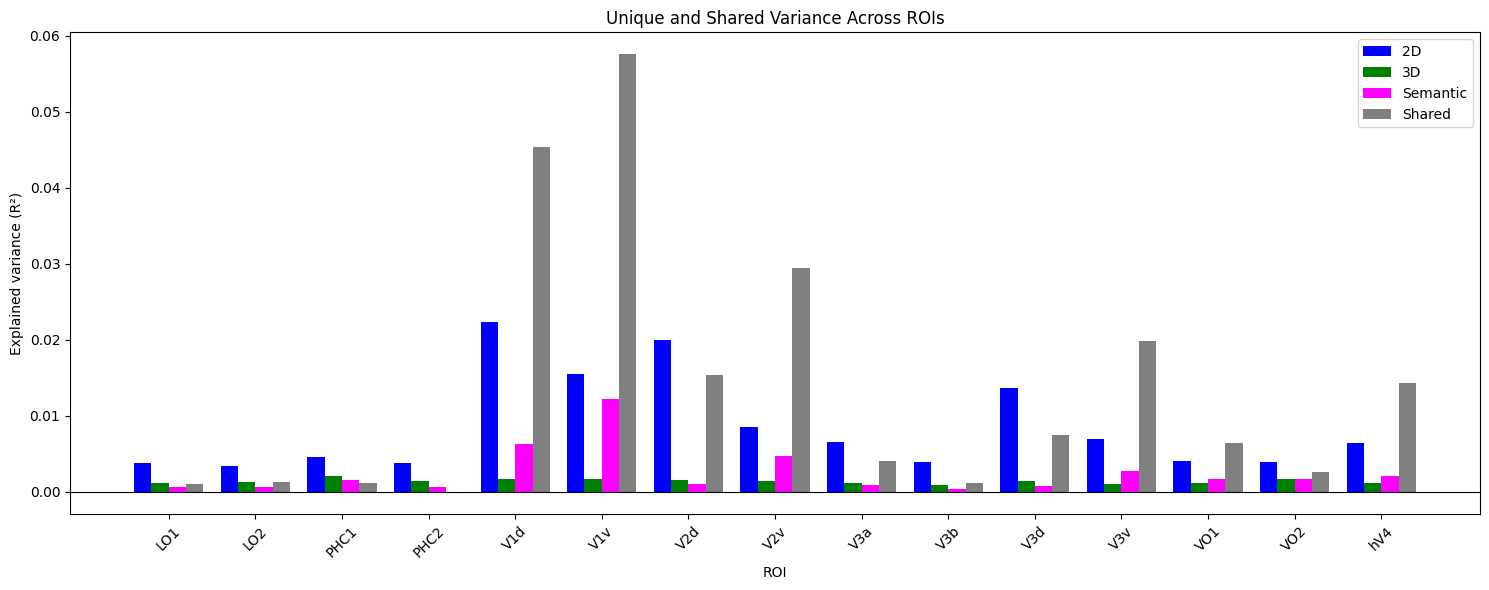

Saved to: D:\Unravelling-Brain-Func-LAION\Ruxandra\results


In [15]:
# Save UVP results

os.makedirs(results_dir, exist_ok=True)

# Save subject-level results
uvp_df.to_csv(
    os.path.join(results_dir, "UVP_all_ROIs.csv"),
    index=False
)

# Save ROI averages
uvp_summary.to_csv(
    os.path.join(results_dir, "UVP_summary_ROIs.csv"),
    index=False
)

# Save plot
plt.figure(figsize=(15, 6))

x = np.arange(len(uvp_summary))
width = 0.20

plt.bar(x - 1.5*width, uvp_summary["Unique_2D"],
        width, label="2D", color="blue")

plt.bar(x - 0.5*width, uvp_summary["Unique_3D"],
        width, label="3D", color="green")

plt.bar(x + 0.5*width, uvp_summary["Unique_Semantic"],
        width, label="Semantic", color="magenta")

plt.bar(x + 1.5*width, uvp_summary["Shared"],
        width, label="Shared", color="gray")

plt.xticks(x, uvp_summary["ROI"], rotation=45)
plt.ylabel("Explained variance (R²)")
plt.xlabel("ROI")
plt.title("Unique and Shared Variance Across ROIs")
plt.axhline(0, linewidth=0.8, color="black")
plt.legend()

plt.tight_layout()

plot_path = os.path.join(results_dir, "UVP_all_ROIs.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", results_dir)

In [17]:
# Check UVP decomposition

check_df = uvp_df.copy()

check_df["Sum_unique_shared"] = (
    check_df["Unique_2D"]
    + check_df["Unique_3D"]
    + check_df["Unique_Semantic"]
    + check_df["Shared"]
)

check_df["Difference"] = (
    check_df["R2_full"] - check_df["Sum_unique_shared"]
)

print(
    check_df[
        ["ROI", "Subject", "R2_full",
         "Unique_2D", "Unique_3D", "Unique_Semantic",
         "Shared", "Sum_unique_shared", "Difference"]
    ].head(20)
)

print("\nMaximum absolute difference:")
print(check_df["Difference"].abs().max())

    ROI  Subject   R2_full  Unique_2D  Unique_3D  Unique_Semantic    Shared  \
0   hV4        1  0.007387   0.001000   0.001124         0.000027  0.005236   
1   hV4        2  0.008775   0.003358   0.000545         0.000339  0.004533   
2   hV4        3  0.004765   0.003118   0.000740         0.000170  0.000737   
3   hV4        4  0.069800   0.015804   0.001196         0.001138  0.051663   
4   hV4        5  0.063555   0.012347   0.000483         0.002792  0.047933   
5   hV4        6  0.002586   0.001283   0.000676         0.000399  0.000228   
6   hV4        7  0.043357   0.015492   0.000191         0.001545  0.026129   
7   hV4        8  0.014532   0.002601   0.000085         0.002070  0.009776   
8   hV4        9  0.065394   0.015990   0.004725         0.013881  0.030798   
9   hV4       10  0.026616   0.012215   0.000134         0.000080  0.014186   
10  hV4       11  0.009622   0.004983   0.001839         0.001073  0.001727   
11  hV4       12  0.036925   0.003014   0.000017    

In [18]:
# Inspect one UVP example in detail

roi = "V1v"
subject_idx = 0

y = brain_vectors[roi][subject_idx]

model_full = LinearRegression().fit(X, y)
r2_full = r2_score(y, model_full.predict(X))

X_no_2d = np.column_stack([rdm_3d, rdm_semantic])
model_no_2d = LinearRegression().fit(X_no_2d, y)
r2_no_2d = r2_score(y, model_no_2d.predict(X_no_2d))

print("Full model R²:", r2_full)
print("Without 2D R²:", r2_no_2d)
print("Unique 2D:", r2_full - r2_no_2d)
print("Stored Unique 2D:", uvp_df[
    (uvp_df["ROI"] == roi) &
    (uvp_df["Subject"] == subject_idx + 1)
]["Unique_2D"].iloc[0])

Full model R²: 0.06404664870965737
Without 2D R²: 0.05324263796641915
Unique 2D: 0.010804010743238224
Stored Unique 2D: 0.010804010743238224


In [19]:
import os

net2brain_root = r"D:\Net2Brain"

rdm_folders = [
    f for f in os.listdir(net2brain_root)
    if f.endswith("_RDM") and os.path.isdir(os.path.join(net2brain_root, f))
]

print("Found RDM folders:", len(rdm_folders))

for folder in sorted(rdm_folders):
    path = os.path.join(net2brain_root, folder)

    files = [
        f for f in os.listdir(path)
        if f.endswith(".npz")
    ]

    print("\n", folder)
    print(files)

Found RDM folders: 33

 autoencoding_RDM
['RDM_bn1.npz', 'RDM_compress1.npz', 'RDM_compress_bn.npz', 'RDM_conv1.npz', 'RDM_groupnorm.npz', 'RDM_layer1.npz', 'RDM_layer2.npz', 'RDM_layer3.npz', 'RDM_layer4.npz', 'RDM_maxpool.npz', 'RDM_relu.npz', 'RDM_relu1.npz']

 class_object_RDM
['RDM_bn1.npz', 'RDM_compress1.npz', 'RDM_compress_bn.npz', 'RDM_conv1.npz', 'RDM_groupnorm.npz', 'RDM_layer1.npz', 'RDM_layer2.npz', 'RDM_layer3.npz', 'RDM_layer4.npz', 'RDM_maxpool.npz', 'RDM_relu.npz', 'RDM_relu1.npz']

 class_scene_RDM
['RDM_bn1.npz', 'RDM_compress1.npz', 'RDM_compress_bn.npz', 'RDM_conv1.npz', 'RDM_groupnorm.npz', 'RDM_layer1.npz', 'RDM_layer2.npz', 'RDM_layer3.npz', 'RDM_layer4.npz', 'RDM_maxpool.npz', 'RDM_relu.npz', 'RDM_relu1.npz']

 colorization_RDM
['RDM_bn1.npz', 'RDM_compress1.npz', 'RDM_compress_bn.npz', 'RDM_conv1.npz', 'RDM_groupnorm.npz', 'RDM_layer1.npz', 'RDM_layer2.npz', 'RDM_layer3.npz', 'RDM_layer4.npz', 'RDM_maxpool.npz', 'RDM_relu.npz', 'RDM_relu1.npz']

 curvature_RDM

In [20]:
from net2brain.feature_extraction import FeatureExtractor

extractor = FeatureExtractor(
    netset="Taskonomy",
    model_name="depth",
    device="cpu"
)

print(extractor.model)

c:\Users\morux\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: FeatureExtractor.__init__() got an unexpected keyword argument 'model_name'

In [21]:
import inspect
from net2brain.feature_extraction import FeatureExtractor

print(inspect.signature(FeatureExtractor))

(model, netset=None, netset_fallback='Standard', device='cpu', pretrained=True, preprocessor=None, extraction_function=None, feature_cleaner=None)


In [22]:
from net2brain.feature_extraction import FeatureExtractor

extractor = FeatureExtractor(
    "depth",
    netset="Taskonomy",
    device="cpu"
)

print(extractor.model)

TaskonomyEncoder(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64,

In [23]:
import inspect

print(inspect.getsource(extractor.model.forward))

    def forward(self, x):
        x = F.pad(x, pad=(3,3,3,3), mode='constant', value=0)
        #  other modes are reflect, replicate, constant

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        # x = F.pad(x, (0,1,0,1), 'constant', 0)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.compress1(x)
        x = self.compress_bn(x)
        x = self.relu1(x)
        if self.normalize_outputs:
            x = self.groupnorm(x)
        return x



In [24]:
print("normalize_outputs:", extractor.model.normalize_outputs)
print("layers_to_extract:", extractor.layers_to_extract)

normalize_outputs: True
layers_to_extract: ['layer1', 'layer2', 'layer3', 'layer4']


In [25]:
# Compare grouped RDMs with averages of layer4 and groupnorm RDMs

groups = {
    "2D": [
        "autoencoding", "colorization", "denoising",
        "edge_texture", "inpainting", "keypoints2d",
        "segment_unsup2d"
    ],
    "3D": [
        "curvature", "edge_occlusion", "keypoints3d",
        "reshading", "euclidean", "depth",
        "normal", "segment_unsup25d"
    ],
    "Semantic": [
        "class_object", "class_scene", "segment_semantic"
    ]
}

for group_name, models in groups.items():

    print("\n" + group_name)

    for layer in ["layer4", "groupnorm"]:
        rdms = []

        for model in models:
            path = os.path.join(
                r"D:\Net2Brain",
                f"{model}_RDM",
                f"RDM_{layer}.npz"
            )

            if os.path.exists(path):
                data = np.load(path, allow_pickle=True)
                key = data.files[0]
                rdms.append(data[key])

        print(layer, "models found:", len(rdms))


2D
layer4 models found: 7
groupnorm models found: 7

3D
layer4 models found: 7
groupnorm models found: 7

Semantic
layer4 models found: 3
groupnorm models found: 3


In [26]:
models_3d = [
    "curvature", "edge_occlusion", "keypoints3d",
    "reshading", "euclidean", "depth",
    "normal", "segment_unsup25d"
]

for model in models_3d:
    path = os.path.join(
        r"D:\Net2Brain",
        f"{model}_RDM",
        "RDM_layer4.npz"
    )

    print(model, "->", os.path.exists(path))

curvature -> True
edge_occlusion -> True
keypoints3d -> True
reshading -> True
euclidean -> False
depth -> True
normal -> True
segment_unsup25d -> True


In [27]:
[f for f in os.listdir(r"D:\Net2Brain") if "euclid" in f.lower()]

[]

In [28]:
import os
os.environ["TORCH_HOME"] = r"D:\torch_cache"

from net2brain.feature_extraction import FeatureExtractor
from net2brain.rdm_creation import RDMCreator

stimuli_path = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\stimuli_data"

extractor = FeatureExtractor(
    "euclidean",
    netset="Taskonomy",
    device="cpu"
)

extractor.extract(
    stimuli_path,
    save_path=r"D:\Net2Brain\euclidean_features"
)

creator = RDMCreator(
    feature_path=r"D:\Net2Brain\euclidean_features"
)

creator.create_rdms(
    save_path=r"D:\Net2Brain\euclidean_RDM"
)

print("Euclidean finished.")

Downloading: "https://github.com/alexsax/visual-prior/raw/networks/assets/pytorch/depth_euclidean_encoder-88f18d41313de7dbc88314a7f0feec3023047303d94d73eb8622dc40334ef149.pth" to D:\torch_cache\hub\checkpoints\depth_euclidean_encoder-88f18d41313de7dbc88314a7f0feec3023047303d94d73eb8622dc40334ef149.pth


100%|██████████| 90.5M/90.5M [00:08<00:00, 11.5MB/s]
Processing files: 100%|██████████| 50/50 [00:17<00:00,  2.86it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:05<00:00,  9.75it/s]


TypeError: RDMCreator.__init__() got an unexpected keyword argument 'feature_path'

In [29]:
import inspect
from net2brain.rdm_creation import RDMCreator

print(inspect.signature(RDMCreator))

(device: Union[str, torch.device] = 'cpu', verbose: bool = False)


In [30]:
import inspect

creator = RDMCreator(device="cpu")

print(inspect.signature(creator.create_rdms))

(feature_path: Union[str, pathlib.Path], save_path: Union[str, pathlib.Path, NoneType] = None, save_format: Literal['pt', 'npz'] = 'npz', distance: Union[str, Callable] = 'pearson', standardize_on_dim: Optional[int] = None, chunk_size: Optional[int] = None, multi_timepoint_rdms: Optional[str] = None, pooling: Optional[str] = None, dim_reduction: Optional[str] = None, n_samples_estim: int = 100, n_components: Optional[int] = 10000, srp_before_pca: bool = False, max_dim_allowed: Optional[int] = None, **kwargs) -> pathlib.Path


In [31]:
from net2brain.rdm_creation import RDMCreator

creator = RDMCreator(device="cpu")

creator.create_rdms(
    feature_path=r"D:\Net2Brain\euclidean_features",
    save_path=r"D:\Net2Brain\euclidean_RDM",
    save_format="npz",
    distance="pearson"
)

print("Euclidean RDMs finished.")

c:\Users\morux\AppData\Local\Programs\Python\Python310\lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Euclidean RDMs finished.


In [32]:
print(
    os.path.exists(
        r"D:\Net2Brain\euclidean_RDM\RDM_layer4.npz"
    )
)

print(
    os.path.exists(
        r"D:\Net2Brain\euclidean_RDM\RDM_groupnorm.npz"
    )
)

True
True


In [33]:
models_3d = [
    "curvature",
    "edge_occlusion",
    "keypoints3d",
    "reshading",
    "euclidean",
    "depth",
    "normal",
    "segment_unsup25d"
]

rdms_3d = []

for model in models_3d:
    path = os.path.join(
        r"D:\Net2Brain",
        f"{model}_RDM",
        "RDM_layer4.npz"
    )

    data = np.load(path, allow_pickle=True)
    key = data.files[0]
    rdms_3d.append(data[key])

rdm_3d_new = np.mean(np.stack(rdms_3d), axis=0)

print("Models used:", len(rdms_3d))
print("New 3D RDM shape:", rdm_3d_new.shape)

ValueError: all input arrays must have the same shape

In [34]:
for model in models_3d:
    path = os.path.join(
        r"D:\Net2Brain",
        f"{model}_RDM",
        "RDM_layer4.npz"
    )

    data = np.load(path, allow_pickle=True)
    key = data.files[0]
    arr = data[key]

    print(model, "->", arr.shape)

curvature -> (0,)
edge_occlusion -> (0,)
keypoints3d -> (0,)
reshading -> (0,)
euclidean -> (1225,)
depth -> (0,)
normal -> (0,)
segment_unsup25d -> (0,)


In [35]:
model = "depth"

path = os.path.join(
    r"D:\Net2Brain",
    f"{model}_RDM",
    "RDM_layer4.npz"
)

data = np.load(path, allow_pickle=True)

print("Keys:", data.files)

for key in data.files:
    print(
        "Key:", key,
        "| shape:", data[key].shape,
        "| dtype:", data[key].dtype
    )
    print(data[key])

Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Key: rdm | shape: (0,) | dtype: float32
[]
Key: stimuli_name | shape: (1,) | dtype: <U4
['test']
Key: layer_name | shape: () | dtype: <U6
layer4
Key: meta | shape: () | dtype: object
{'distance': 'pearson', 'multi_timepoint_rdms': None}


In [36]:
model = "depth"

feature_dir = os.path.join(
    r"D:\Net2Brain",
    f"{model}_features"
)

print("Feature folder exists:", os.path.exists(feature_dir))

if os.path.exists(feature_dir):
    items = os.listdir(feature_dir)
    print("Number of items:", len(items))
    print("First items:", items[:20])

Feature folder exists: True
Number of items: 12
First items: ['consolidated_bn1.npz', 'consolidated_compress1.npz', 'consolidated_compress_bn.npz', 'consolidated_conv1.npz', 'consolidated_groupnorm.npz', 'consolidated_layer1.npz', 'consolidated_layer2.npz', 'consolidated_layer3.npz', 'consolidated_layer4.npz', 'consolidated_maxpool.npz', 'consolidated_relu.npz', 'consolidated_relu1.npz']


In [37]:
path = r"D:\Net2Brain\depth_features\consolidated_layer4.npz"

data = np.load(path, allow_pickle=True)

print("Keys:", data.files)

for key in data.files:
    print(key, "->", data[key].shape)

Keys: ['test']
test -> (1, 2048, 14, 14)


In [38]:
import os
os.environ["TORCH_HOME"] = r"D:\torch_cache"

from net2brain.feature_extraction import FeatureExtractor
from net2brain.rdm_creation import RDMCreator

stimuli_path = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\stimuli_data"

# New folders so we don't overwrite the old files yet
feature_path = r"D:\Net2Brain\depth_features_50"
rdm_path = r"D:\Net2Brain\depth_RDM_50"

extractor = FeatureExtractor(
    "depth",
    netset="Taskonomy",
    device="cpu"
)

extractor.extract(
    stimuli_path,
    save_path=feature_path
)

creator = RDMCreator(device="cpu")

creator.create_rdms(
    feature_path=feature_path,
    save_path=rdm_path,
    save_format="npz",
    distance="pearson"
)

print("Depth finished.")

Processing files: 100%|██████████| 50/50 [00:18<00:00,  2.75it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:04<00:00, 10.37it/s]


Depth finished.


In [39]:
path = r"D:\Net2Brain\depth_RDM_50\RDM_layer4.npz"

data = np.load(path, allow_pickle=True)

print("Keys:", data.files)
print("RDM shape:", data["rdm"].shape)
print("Number of stimuli:", len(data["stimuli_name"]))

Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
RDM shape: (1225,)
Number of stimuli: 50


In [40]:
import os
os.environ["TORCH_HOME"] = r"D:\torch_cache"

from net2brain.feature_extraction import FeatureExtractor
from net2brain.rdm_creation import RDMCreator

stimuli_path = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\stimuli_data"

models_to_process = [
    "curvature",
    "edge_occlusion",
    "keypoints3d",
    "reshading",
    "normal",
    "segment_unsup25d"
]

for model in models_to_process:
    print("\nProcessing:", model)

    feature_path = rf"D:\Net2Brain\{model}_features_50"
    rdm_path = rf"D:\Net2Brain\{model}_RDM_50"

    extractor = FeatureExtractor(
        model,
        netset="Taskonomy",
        device="cpu"
    )

    extractor.extract(
        stimuli_path,
        save_path=feature_path
    )

    creator = RDMCreator(device="cpu")

    creator.create_rdms(
        feature_path=feature_path,
        save_path=rdm_path,
        save_format="npz",
        distance="pearson"
    )

    print(model, "finished.")

print("\nAll remaining 3D models finished.")


Processing: curvature


Processing files: 100%|██████████| 50/50 [00:19<00:00,  2.55it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:06<00:00,  7.20it/s]


curvature finished.

Processing: edge_occlusion


...

normal finished.

Processing: segment_unsup25d


Processing files: 100%|██████████| 50/50 [00:16<00:00,  3.04it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:04<00:00, 10.72it/s]


segment_unsup25d finished.

All remaining 3D models finished.


In [41]:
models_3d = [
    "curvature",
    "edge_occlusion",
    "keypoints3d",
    "reshading",
    "euclidean",
    "depth",
    "normal",
    "segment_unsup25d"
]

rdms_3d = []

for model in models_3d:

    if model == "euclidean":
        path = rf"D:\Net2Brain\{model}_RDM\RDM_layer4.npz"
    else:
        path = rf"D:\Net2Brain\{model}_RDM_50\RDM_layer4.npz"

    data = np.load(path, allow_pickle=True)
    rdm = data["rdm"]

    print(model, "->", rdm.shape)

    rdms_3d.append(rdm)

rdm_3d_new = np.mean(np.stack(rdms_3d), axis=0)

print("\nModels used:", len(rdms_3d))
print("New 3D RDM shape:", rdm_3d_new.shape)

curvature -> (1225,)
edge_occlusion -> (1225,)
keypoints3d -> (1225,)
reshading -> (1225,)
euclidean -> (1225,)
depth -> (1225,)
normal -> (1225,)
segment_unsup25d -> (1225,)

Models used: 8
New 3D RDM shape: (1225,)


In [42]:
new_3d_path = os.path.join(results_dir, "3D_RDM.npz")

np.savez(
    new_3d_path,
    rdm=rdm_3d_new
)

print("Saved:", new_3d_path)

check = np.load(new_3d_path, allow_pickle=True)["rdm"]
print("Saved shape:", check.shape)

Saved: D:\Unravelling-Brain-Func-LAION\Ruxandra\results\3D_RDM.npz
Saved shape: (1225,)


In [43]:
groups_to_check = {
    "2D": [
        "autoencoding",
        "colorization",
        "denoising",
        "edge_texture",
        "inpainting",
        "keypoints2d",
        "segment_unsup2d"
    ],
    "Semantic": [
        "class_object",
        "class_scene",
        "segment_semantic"
    ]
}

for group_name, models in groups_to_check.items():
    print("\n" + group_name)

    for model in models:
        path = rf"D:\Net2Brain\{model}_RDM\RDM_layer4.npz"

        data = np.load(path, allow_pickle=True)
        rdm = data["rdm"]

        print(model, "->", rdm.shape)


2D
autoencoding -> (0,)
colorization -> (0,)
denoising -> (0,)
edge_texture -> (0,)
inpainting -> (0,)
keypoints2d -> (0,)
segment_unsup2d -> (0,)

Semantic
class_object -> (0,)
class_scene -> (0,)
segment_semantic -> (0,)


In [44]:
import os
os.environ["TORCH_HOME"] = r"D:\torch_cache"

from net2brain.feature_extraction import FeatureExtractor
from net2brain.rdm_creation import RDMCreator

stimuli_path = r"D:\Net2Brain\notebooks\Workshops\bonner_extracted\bonner_pnas2017\stimuli_data"

models_to_process = [
    # 2D
    "autoencoding",
    "colorization",
    "denoising",
    "edge_texture",
    "inpainting",
    "keypoints2d",
    "segment_unsup2d",

    # Semantic
    "class_object",
    "class_scene",
    "segment_semantic"
]

for model in models_to_process:

    print("\n==============================")
    print("Processing:", model)
    print("==============================")

    feature_path = rf"D:\Net2Brain\{model}_features_50"
    rdm_path = rf"D:\Net2Brain\{model}_RDM_50"

    extractor = FeatureExtractor(
        model,
        netset="Taskonomy",
        device="cpu"
    )

    extractor.extract(
        stimuli_path,
        save_path=feature_path
    )

    creator = RDMCreator(device="cpu")

    creator.create_rdms(
        feature_path=feature_path,
        save_path=rdm_path,
        save_format="npz",
        distance="pearson"
    )

    print(model, "finished.")

print("\nALL 2D AND SEMANTIC MODELS FINISHED.")


Processing: autoencoding


Processing files: 100%|██████████| 50/50 [00:18<00:00,  2.75it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:04<00:00, 10.37it/s]


autoencoding finished.

Processing: colorization


...

class_scene finished.

Processing: segment_semantic


Processing files: 100%|██████████| 50/50 [00:16<00:00,  3.04it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:04<00:00, 11.51it/s]


segment_semantic finished.

ALL 2D AND SEMANTIC MODELS FINISHED.


In [45]:
models_2d = [
    "autoencoding",
    "colorization",
    "denoising",
    "edge_texture",
    "inpainting",
    "keypoints2d",
    "segment_unsup2d"
]

models_semantic = [
    "class_object",
    "class_scene",
    "segment_semantic"
]

def average_group_rdms(models):
    rdms = []

    for model in models:
        path = rf"D:\Net2Brain\{model}_RDM_50\RDM_layer4.npz"

        data = np.load(path, allow_pickle=True)
        rdm = data["rdm"]

        print(model, "->", rdm.shape)

        rdms.append(rdm)

    return np.mean(np.stack(rdms), axis=0)


print("=== 2D ===")
rdm_2d_new = average_group_rdms(models_2d)

print("\n2D models:", len(models_2d))
print("2D grouped RDM:", rdm_2d_new.shape)


print("\n=== SEMANTIC ===")
rdm_semantic_new = average_group_rdms(models_semantic)

print("\nSemantic models:", len(models_semantic))
print("Semantic grouped RDM:", rdm_semantic_new.shape)

=== 2D ===
autoencoding -> (1225,)
colorization -> (1225,)
denoising -> (1225,)
edge_texture -> (1225,)
inpainting -> (1225,)
keypoints2d -> (1225,)
segment_unsup2d -> (1225,)

2D models: 7
2D grouped RDM: (1225,)

=== SEMANTIC ===
class_object -> (1225,)
class_scene -> (1225,)
segment_semantic -> (1225,)

Semantic models: 3
Semantic grouped RDM: (1225,)


In [46]:
# Update variables
rdm_2d = rdm_2d_new
rdm_3d = rdm_3d_new
rdm_semantic = rdm_semantic_new

# Save grouped RDMs
np.savez(
    os.path.join(results_dir, "2D_RDM.npz"),
    rdm=rdm_2d
)

np.savez(
    os.path.join(results_dir, "3D_RDM.npz"),
    rdm=rdm_3d
)

np.savez(
    os.path.join(results_dir, "Semantic_RDM.npz"),
    rdm=rdm_semantic
)

print("2D:", rdm_2d.shape)
print("3D:", rdm_3d.shape)
print("Semantic:", rdm_semantic.shape)
print("Grouped RDMs saved.")

2D: (1225,)
3D: (1225,)
Semantic: (1225,)
Grouped RDMs saved.


In [49]:
X = np.column_stack([
    rdm_2d,
    rdm_3d,
    rdm_semantic
])

print("Predictor matrix shape:", X.shape)

Predictor matrix shape: (1225, 3)


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

results = []

for roi, subject_vectors in brain_vectors.items():

    for subject_idx, y in enumerate(subject_vectors):

        # Full model: 2D + 3D + Semantic
        full_model = LinearRegression().fit(X, y)
        full_pred = full_model.predict(X)
        r2_full = r2_score(y, full_pred)

        # Without 2D
        X_no_2d = np.column_stack([rdm_3d, rdm_semantic])
        model_no_2d = LinearRegression().fit(X_no_2d, y)
        r2_no_2d = r2_score(
            y,
            model_no_2d.predict(X_no_2d)
        )

        # Without 3D
        X_no_3d = np.column_stack([rdm_2d, rdm_semantic])
        model_no_3d = LinearRegression().fit(X_no_3d, y)
        r2_no_3d = r2_score(
            y,
            model_no_3d.predict(X_no_3d)
        )

        # Without Semantic
        X_no_sem = np.column_stack([rdm_2d, rdm_3d])
        model_no_sem = LinearRegression().fit(X_no_sem, y)
        r2_no_sem = r2_score(
            y,
            model_no_sem.predict(X_no_sem)
        )

        # Unique variance
        unique_2d = r2_full - r2_no_2d
        unique_3d = r2_full - r2_no_3d
        unique_semantic = r2_full - r2_no_sem

        # Remaining shared variance
        shared = (
            r2_full
            - unique_2d
            - unique_3d
            - unique_semantic
        )

        results.append({
            "ROI": roi,
            "Subject": subject_idx + 1,
            "R2_full": r2_full,
            "Unique_2D": unique_2d,
            "Unique_3D": unique_3d,
            "Unique_Semantic": unique_semantic,
            "Shared": shared
        })

uvp_df = pd.DataFrame(results)

print(uvp_df.head())
print("\nRows:", len(uvp_df))

   ROI  Subject   R2_full  Unique_2D     Unique_3D  Unique_Semantic    Shared
0  hV4        1  0.006983   0.001046  7.209817e-04     7.160815e-07  0.005216
1  hV4        2  0.008718   0.003171  4.886845e-04     3.013095e-04  0.004757
2  hV4        3  0.004968   0.003311  9.429269e-04     2.037758e-04  0.000510
3  hV4        4  0.068604   0.018657  1.854645e-08     2.839304e-03  0.047108
4  hV4        5  0.063204   0.014965  1.324543e-04     5.139637e-03  0.042967

Rows: 240


In [51]:
uvp_summary = (
    uvp_df
    .groupby("ROI")[[
        "R2_full",
        "Unique_2D",
        "Unique_3D",
        "Unique_Semantic",
        "Shared"
    ]]
    .mean()
    .reset_index()
)

print(uvp_summary)

     ROI   R2_full  Unique_2D  Unique_3D  Unique_Semantic    Shared
0    LO1  0.006656   0.003943   0.001362         0.000581  0.000771
1    LO2  0.006639   0.003500   0.001527         0.000636  0.000977
2   PHC1  0.009526   0.004827   0.002258         0.001587  0.000853
3   PHC2  0.005942   0.003953   0.001581         0.000678 -0.000270
4    V1d  0.077585   0.025505   0.003641         0.008638  0.039802
5    V1v  0.088758   0.018558   0.003523         0.016197  0.050479
6    V2d  0.039123   0.021617   0.002677         0.001440  0.013389
7    V2v  0.044512   0.010094   0.001875         0.006562  0.025981
8    V3a  0.013026   0.007019   0.001489         0.001016  0.003502
9    V3b  0.006505   0.004131   0.001039         0.000388  0.000946
10   V3d  0.023832   0.014439   0.002012         0.000886  0.006495
11   V3v  0.030685   0.008056   0.001308         0.003780  0.017540
12   VO1  0.013466   0.004453   0.001438         0.001972  0.005602
13   VO2  0.010036   0.004128   0.001895        

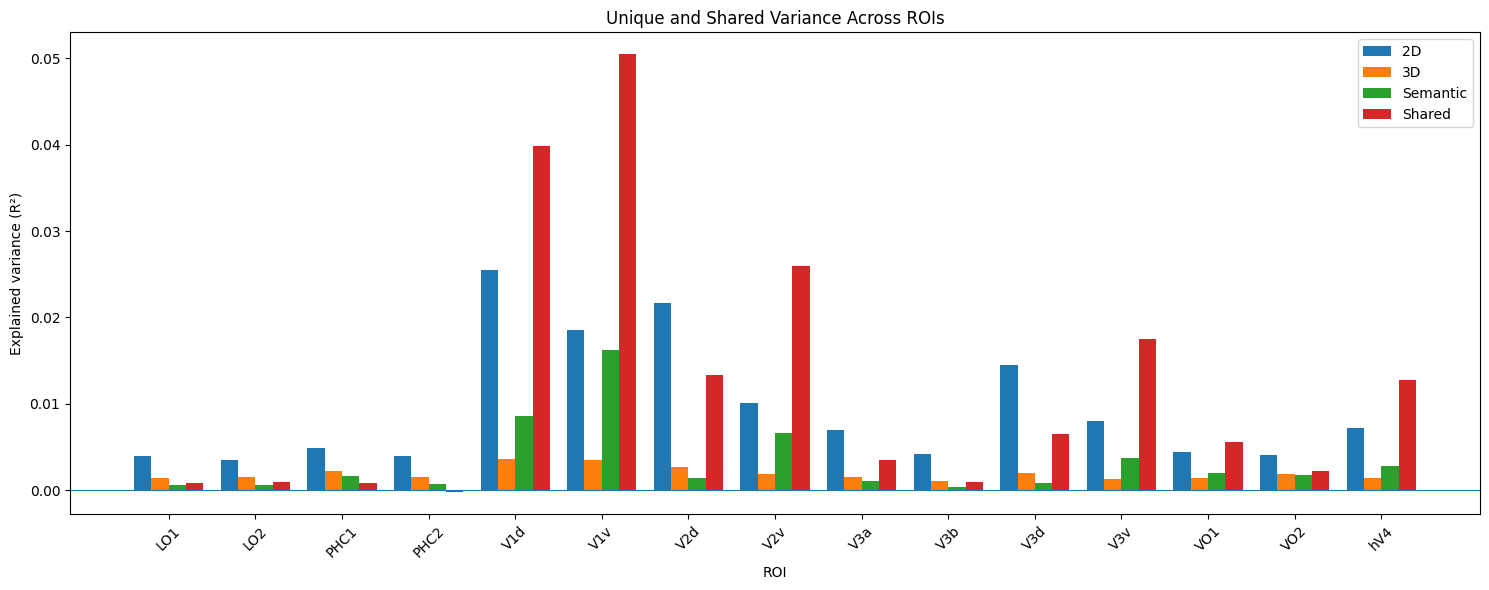

In [52]:
x = np.arange(len(uvp_summary))
width = 0.20

plt.figure(figsize=(15, 6))

plt.bar(
    x - 1.5 * width,
    uvp_summary["Unique_2D"],
    width,
    label="2D"
)

plt.bar(
    x - 0.5 * width,
    uvp_summary["Unique_3D"],
    width,
    label="3D"
)

plt.bar(
    x + 0.5 * width,
    uvp_summary["Unique_Semantic"],
    width,
    label="Semantic"
)

plt.bar(
    x + 1.5 * width,
    uvp_summary["Shared"],
    width,
    label="Shared"
)

plt.xticks(
    x,
    uvp_summary["ROI"],
    rotation=45
)

plt.ylabel("Explained variance (R²)")
plt.xlabel("ROI")
plt.title("Unique and Shared Variance Across ROIs")
plt.axhline(0, linewidth=0.8)
plt.legend()
plt.tight_layout()

plt.show()

In [53]:
os.makedirs(results_dir, exist_ok=True)

# Save complete subject-level UVP results
uvp_df.to_csv(
    os.path.join(results_dir, "UVP_all_ROIs.csv"),
    index=False
)

# Save ROI averages
uvp_summary.to_csv(
    os.path.join(results_dir, "UVP_summary_ROIs.csv"),
    index=False
)

# Save the NEW grouped RDMs
np.savez(
    os.path.join(results_dir, "2D_RDM.npz"),
    rdm=rdm_2d
)

np.savez(
    os.path.join(results_dir, "3D_RDM.npz"),
    rdm=rdm_3d
)

np.savez(
    os.path.join(results_dir, "Semantic_RDM.npz"),
    rdm=rdm_semantic
)

print("Everything saved successfully.")
print(results_dir)

Everything saved successfully.
D:\Unravelling-Brain-Func-LAION\Ruxandra\results
